In [1]:
import os
import json
import pandas as pd
from pathlib import Path
import torch


In [2]:
BASE_PATH = Path(".")
print(f"Базовый путь проекта: {BASE_PATH}")

IMAGES_TRAIN_PATH = Path("/storage/dremov/diploma/datasets/train_vlm_300")
print(f"Путь к изображениям для обучения: {IMAGES_TRAIN_PATH}")

FEATURES_AND_LABELS = BASE_PATH / "5_1_features_for_vlm.xlsx"
print(f"Путь к файлу признаков и меток: {FEATURES_AND_LABELS}")


Базовый путь проекта: .
Путь к изображениям для обучения: /storage/dremov/diploma/datasets/train_vlm_300
Путь к файлу признаков и меток: 5_1_features_for_vlm.xlsx


In [3]:
HF_CACHE_DIR = BASE_PATH / "hf_cache"
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE_DIR)
print(f"Каталог кэша Hugging Face: {os.environ['HF_HOME']}")


Каталог кэша Hugging Face: hf_cache


In [4]:
df = pd.read_excel(str(FEATURES_AND_LABELS), dtype=str).fillna("")
df.shape


(8430, 16)

In [5]:
df.columns.tolist()


['Код-идентификатор обследуемого',
 'Размер рисунка',
 'Способ изображения',
 'Аккуратность рисунка',
 'Штриховка',
 'Детализированность',
 'Стирания, исправления',
 'Устойчивость изображенного человека',
 'Ресницы',
 'Зубы',
 'Дополнительные детали на лице (брови)',
 'Дополнительные детали на лице (усы и / или борода)',
 'Положение рук (подняты)',
 'Положение рук (за спиной или в карманах)',
 'Пол (признаки пола подчеркнуты)',
 'Одежда (реалистичное изображение)']

In [6]:
from __future__ import annotations

from datasets import Dataset
from datasets import Image as HFImage

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}


def index_images(images_dir: Path) -> dict[str, Path]:
    index: dict[str, Path] = {}
    if not images_dir.is_dir():
        return index
    for p in images_dir.rglob("*"):
        if not p.is_file():
            continue
        if p.suffix.lower() not in IMAGE_EXTS:
            continue
        index.setdefault(p.stem, p)
    return index


def read_labels(xlsx_path: Path) -> pd.DataFrame:
    df = pd.read_excel(xlsx_path, dtype=str).fillna("")
    id_col = df.columns[0]
    df[id_col] = df[id_col].astype(str).str.strip()
    df = df[df[id_col] != ""].copy()
    df = df.rename(columns={id_col: "identifier"})
    return df


if not IMAGES_TRAIN_PATH.is_dir():
    raise FileNotFoundError(
        "Папка с изображениями не найдена или это не каталог: "
        + str(IMAGES_TRAIN_PATH.resolve())
    )

labels_df = read_labels(FEATURES_AND_LABELS)
img_index = index_images(IMAGES_TRAIN_PATH)

print(f"Строк в Excel: {len(labels_df)}")
print(f"Файлов изображений в индексе: {len(img_index)}, путь: {IMAGES_TRAIN_PATH.resolve()}")

matched_df = labels_df.copy()
matched_df["image_file"] = matched_df["identifier"].map(lambda x: img_index.get(str(x)))
matched_df = matched_df[matched_df["image_file"].notna()].copy()
matched_df["image_file"] = matched_df["image_file"].map(lambda p: str(Path(p).resolve()))
matched_df["image_path"] = matched_df["image_file"].astype(str)

missing = len(labels_df) - len(matched_df)
print(f"Совпало строк разметки с файлами: {len(matched_df)}, без файла: {missing}")

if len(img_index) == 0:
    raise RuntimeError(
        "В указанной папке не найдено ни одного файла с расширениями "
        + str(sorted(IMAGE_EXTS))
        + ". Проверьте путь и формат файлов."
    )

if len(matched_df) == 0:
    ids_sample = labels_df["identifier"].head(25).tolist()
    stems_sample = sorted(img_index.keys())[:25]
    raise RuntimeError(
        "Ни одна строка Excel не сопоставилась с изображениями: "
        "имя файла без расширения должно совпадать с первым столбцом (identifier). "
        "Примеры identifier из Excel: "
        + str(ids_sample)
        + ". Примеры stem имён файлов: "
        + str(stems_sample)
        + "."
    )

dataset: Dataset = Dataset.from_pandas(matched_df, preserve_index=False)
dataset = dataset.cast_column("image_file", HFImage(mode="RGB"))
dataset = dataset.rename_column("image_file", "image")

print(f"Колонки датасета: {dataset.column_names}")
print(f"Строк в датасете: {len(dataset)}")


/storage/dremov/diploma/conda_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Строк в Excel: 8430
Файлов изображений в индексе: 7798, путь: /storage/dremov/diploma/datasets/train_vlm_300
Совпало строк разметки с файлами: 7798, без файла: 632
Колонки датасета: ['identifier', 'Размер рисунка', 'Способ изображения', 'Аккуратность рисунка', 'Штриховка', 'Детализированность', 'Стирания, исправления', 'Устойчивость изображенного человека', 'Ресницы', 'Зубы', 'Дополнительные детали на лице (брови)', 'Дополнительные детали на лице (усы и / или борода)', 'Положение рук (подняты)', 'Положение рук (за спиной или в карманах)', 'Пол (признаки пола подчеркнуты)', 'Одежда (реалистичное изображение)', 'image', 'image_path']
Строк в датасете: 7798


In [7]:
from typing import Any, Dict, List

STATS_XLSX_PATH = BASE_PATH / "5_1_statistics_analysis.xlsx"
RESPONSE_FORMAT_JSON_PATH = BASE_PATH / "response_format.json"

use_my_own_rf = True
MY_OWN_RESPONSE_FORMAT_JSON = """
{
  "schema": {
    "type": "object",
    "additionalProperties": false,
    "required": [
      "Размер рисунка",
      "Способ изображения",
      "Аккуратность рисунка",
      "Штриховка",
      "Детализированность",
      "Стирания, исправления",
      "Устойчивость изображенного человека",
      "Ресницы",
      "Зубы",
      "Дополнительные детали на лице (брови)",
      "Дополнительные детали на лице (усы и / или борода)",
      "Положение рук (подняты)",
      "Положение рук (за спиной или в карманах)",
      "Пол (признаки пола подчеркнуты)",
      "Одежда (реалистичное изображение)"
    ],
    "properties": {
      "Размер рисунка": {
        "type": "string",
        "enum": [
          "крупный",
          "стандарт",
          "мелкий"
        ],
        "description": "Определи общий размер рисунка."
      },
      "Способ изображения": {
        "type": "string",
        "enum": [
          "дифференцированная схема",
          "пластический",
          "промежуточный",
          "пластический с элементами схемы",
          "примитивная схема",
          "схема с элементами пластического",
          "условное изображение"
        ],
        "description": "Определи способ изображения персонажа на рисунке."
      },
      "Аккуратность рисунка": {
        "type": "string",
        "enum": [
          "средняя (стандарт)",
          "низкая",
          "высокая"
        ],
        "description": "Определи аккуратность, с которой выполнен рисунок."
      },
      "Штриховка": {
        "type": "string",
        "enum": [
          "нет",
          "есть"
        ],
        "description": "Определи, имеются ли заштрихованные области на рисунке."
      },
      "Детализированность": {
        "type": "string",
        "enum": [
          "средняя (стандарт)",
          "низкая",
          "высокая"
        ],
        "description": "Определи общий уровень детализированности рисунка."
      },
      "Стирания, исправления": {
        "type": "string",
        "enum": [
          "отсутствуют",
          "слабо выражены",
          "средняя выраженность",
          "сильно выражены"
        ],
        "description": "Определи, имеются ли стирания или исправления на рисунке."
      },
      "Устойчивость изображенного человека": {
        "type": "string",
        "enum": [
          "вполне устойчив",
          "относительно устойчив",
          "'висит в воздухе'",
          "неустойчив"
        ],
        "description": "Определи устойчивость изображенного человека (персонажа)."
      },
      "Ресницы": {
        "type": "string",
        "enum": [
          "отсутствуют",
          "имеются, без особенностей",
          "",
          "длинные, загнутые",
          "нарисованы небрежно",
          "другое"
        ],
        "description": "Определи, имеются ли ресницы на лице изображённого персонажа."
      },
      "Зубы": {
        "type": "string",
        "enum": [
          "отсутствуют",
          "",
          "нарисованы, без особенностей",
          "в большом количестве",
          "острые",
          "другое",
          "выделены нажимом"
        ],
        "description": "Определи, имеются ли зубы в области рта у изображённого персонажа."
      },
      "Дополнительные детали на лице (брови)": {
        "type": "string",
        "enum": [
          "",
          "брови"
        ],
        "description": "Определи, имеются ли брови в области глаз у изображённого персонажа."
      },
      "Дополнительные детали на лице (усы и / или борода)": {
        "type": "string",
        "enum": [
          "",
          "усы и / или борода"
        ],
        "description": "Определи, имеются ли усы и / или борода в области рта или подбородка у изображённого персонажа."
      },
      "Положение рук (подняты)": {
        "type": "string",
        "enum": [
          "",
          "подняты"
        ],
        "description": "Определи положение рук у изображённого персонажа. Подняты ли они?"
      },
      "Положение рук (за спиной или в карманах)": {
        "type": "string",
        "enum": [
          "",
          "за спиной или в карманах"
        ],
        "description": "Определи положение рук изображённого персонажа. Руки находятся за спиной или в карманах?"
      },
      "Пол (признаки пола подчеркнуты)": {
        "type": "string",
        "enum": [
          "",
          "признаки пола подчеркнуты"
        ],
        "description": "Определи, подчёркнуты ли признаки пола (половые органы, грудь, бёдра) у изображённого персонажа."
      },
      "Одежда (реалистичное изображение)": {
        "type": "string",
        "enum": [
          "",
          "реалистичное изображение"
        ],
        "description": "Определи, реалистична ли одежда у изображённого персонажа, если она вообще имеется?"
      }
    }
  }
}
"""


BASE_INSTRUCTION = (
    "Задача: проанализировать детский рисунок. "
    "Верни результат строго в JSON формате."
)


def build_response_format(stats_path: Path) -> Dict[str, Any]:
    df = pd.read_excel(stats_path, header=0, dtype=str).fillna("")
    value_cols = [c for c in df.columns if str(c).startswith("Значение_")]

    properties: Dict[str, Any] = {}
    required: List[str] = []

    for _, row in df.iterrows():
        feature = str(row.iloc[0]).strip()
        if not feature:
            continue
        values: List[str] = []
        seen = set()
        for c in value_cols:
            v = str(row[c]).strip().strip("'\"")
            if v and v not in seen:
                values.append(v)
                seen.add(v)
        values = ["" if x == "пусто" else x for x in values]
        values = list(dict.fromkeys(values))
        if not values:
            continue
        properties[feature] = {
            "type": "string",
            "enum": values,
            "description": f"Значение признака '{feature}'.",
        }
        required.append(feature)

    return {
        "instruction": BASE_INSTRUCTION,
        "schema": {
            "type": "object",
            "additionalProperties": False,
            "required": required,
            "properties": properties,
        },
    }


if use_my_own_rf:
    if not MY_OWN_RESPONSE_FORMAT_JSON.strip():
        raise ValueError("Задайте MY_OWN_RESPONSE_FORMAT_JSON при use_my_own_rf=True")
    response_format = json.loads(MY_OWN_RESPONSE_FORMAT_JSON)
    response_format.setdefault("instruction", BASE_INSTRUCTION)
else:
    response_format = build_response_format(STATS_XLSX_PATH)
RESPONSE_FORMAT_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)
RESPONSE_FORMAT_JSON_PATH.write_text(
    json.dumps(response_format, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

instruction = (
    response_format["instruction"]
    + "\n\n"
    + json.dumps(response_format["schema"], ensure_ascii=False, indent=2)
)
REQUIRED_KEYS = list(response_format["schema"]["required"])


In [8]:
import shutil

from datasets import Dataset, concatenate_datasets, load_from_disk

IMAGE_PATH_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")


def conversation_image_ref(sample):
    raw = sample.get("image_path")
    if raw is not None:
        text = str(raw).strip()
        if text:
            return text
    ident = str(sample.get("identifier", "")).strip()
    for ext in IMAGE_PATH_EXTS:
        cand = IMAGES_TRAIN_PATH / f"{ident}{ext}"
        if cand.is_file():
            return str(cand.resolve())
    for hit in IMAGES_TRAIN_PATH.rglob(f"{ident}.*"):
        if hit.is_file() and hit.suffix.lower() in IMAGE_PATH_EXTS:
            return str(hit.resolve())
    raise FileNotFoundError(
        f"Файл изображения для идентификатора {ident!r} не найден в {IMAGES_TRAIN_PATH}"
    )



def message_image_ref(sample):
    for part in sample["messages"][0]["content"]:
        if part.get("type") == "image":
            ref = part.get("image")
            if ref:
                return ref
    raise ValueError("В sample не найден путь к изображению")


def convert_to_conversation(sample):
    label_dict = {}
    for key, value in sample.items():
        if key in ("image", "image_path", "identifier"):
            continue
        if key not in REQUIRED_KEYS:
            continue
        if hasattr(value, "item"):
            value = value.item()
        label_dict[key] = "" if value is None else str(value).strip()

    answer_text = json.dumps(label_dict, ensure_ascii=False)
    image_ref = conversation_image_ref(sample)
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_ref},
                {"type": "text", "text": instruction},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": answer_text},
            ],
        },
    ]
    user_content = conversation[0]["content"]
    if len(user_content) < 2 or user_content[0].get("type") != "image" or user_content[1].get("type") != "text":
        raise ValueError("Некорректный порядок content: ожидается image -> text")

    return {"messages": conversation}


CONVERTED_DISK = BASE_PATH / "converted_conversations_hf"
SHARDS_TMP = BASE_PATH / "converted_conversations_hf_shards_tmp"
SHARD_SIZE = 1000
FORCE_REBUILD = False

if CONVERTED_DISK.exists() and not FORCE_REBUILD:
    converted_dataset = load_from_disk(str(CONVERTED_DISK))
    print(f"Загружено с диска: {CONVERTED_DISK.resolve()}, строк: {len(converted_dataset)}")
else:
    if SHARDS_TMP.exists():
        shutil.rmtree(SHARDS_TMP)
    SHARDS_TMP.mkdir(parents=True, exist_ok=True)

    n = len(dataset)
    if n == 0:
        raise RuntimeError(f"Директория {IMAGES_TRAIN_PATH} пуста. Проверьте путь к изображениям.")
    buffer = []
    shard_id = 0
    print("Начинаем обработку изображений и разметки.")
    for idx in range(n):
        if idx % 250 == 0:
            print(f" - обработка: {idx}/{n}")
        sample = dataset[idx]
        buffer.append(convert_to_conversation(sample))
        if len(buffer) >= SHARD_SIZE or idx == n - 1:
            part_path = SHARDS_TMP / f"part_{shard_id:05d}"
            Dataset.from_list(buffer).save_to_disk(str(part_path))
            buffer.clear()
            shard_id += 1

    parts = [load_from_disk(str(p)) for p in sorted(SHARDS_TMP.iterdir()) if p.is_dir()]
    converted_dataset = concatenate_datasets(parts)
    if CONVERTED_DISK.exists():
        shutil.rmtree(CONVERTED_DISK)
    converted_dataset.save_to_disk(str(CONVERTED_DISK))
    shutil.rmtree(SHARDS_TMP)


Загружено с диска: /storage/dremov/diploma/programs/26-05-22_1_gemma/converted_conversations_hf, строк: 7798


Превью изображения из converted_dataset[14]: /storage/dremov/diploma/datasets/train_vlm_300/ЧУВ5лмдс_39.png


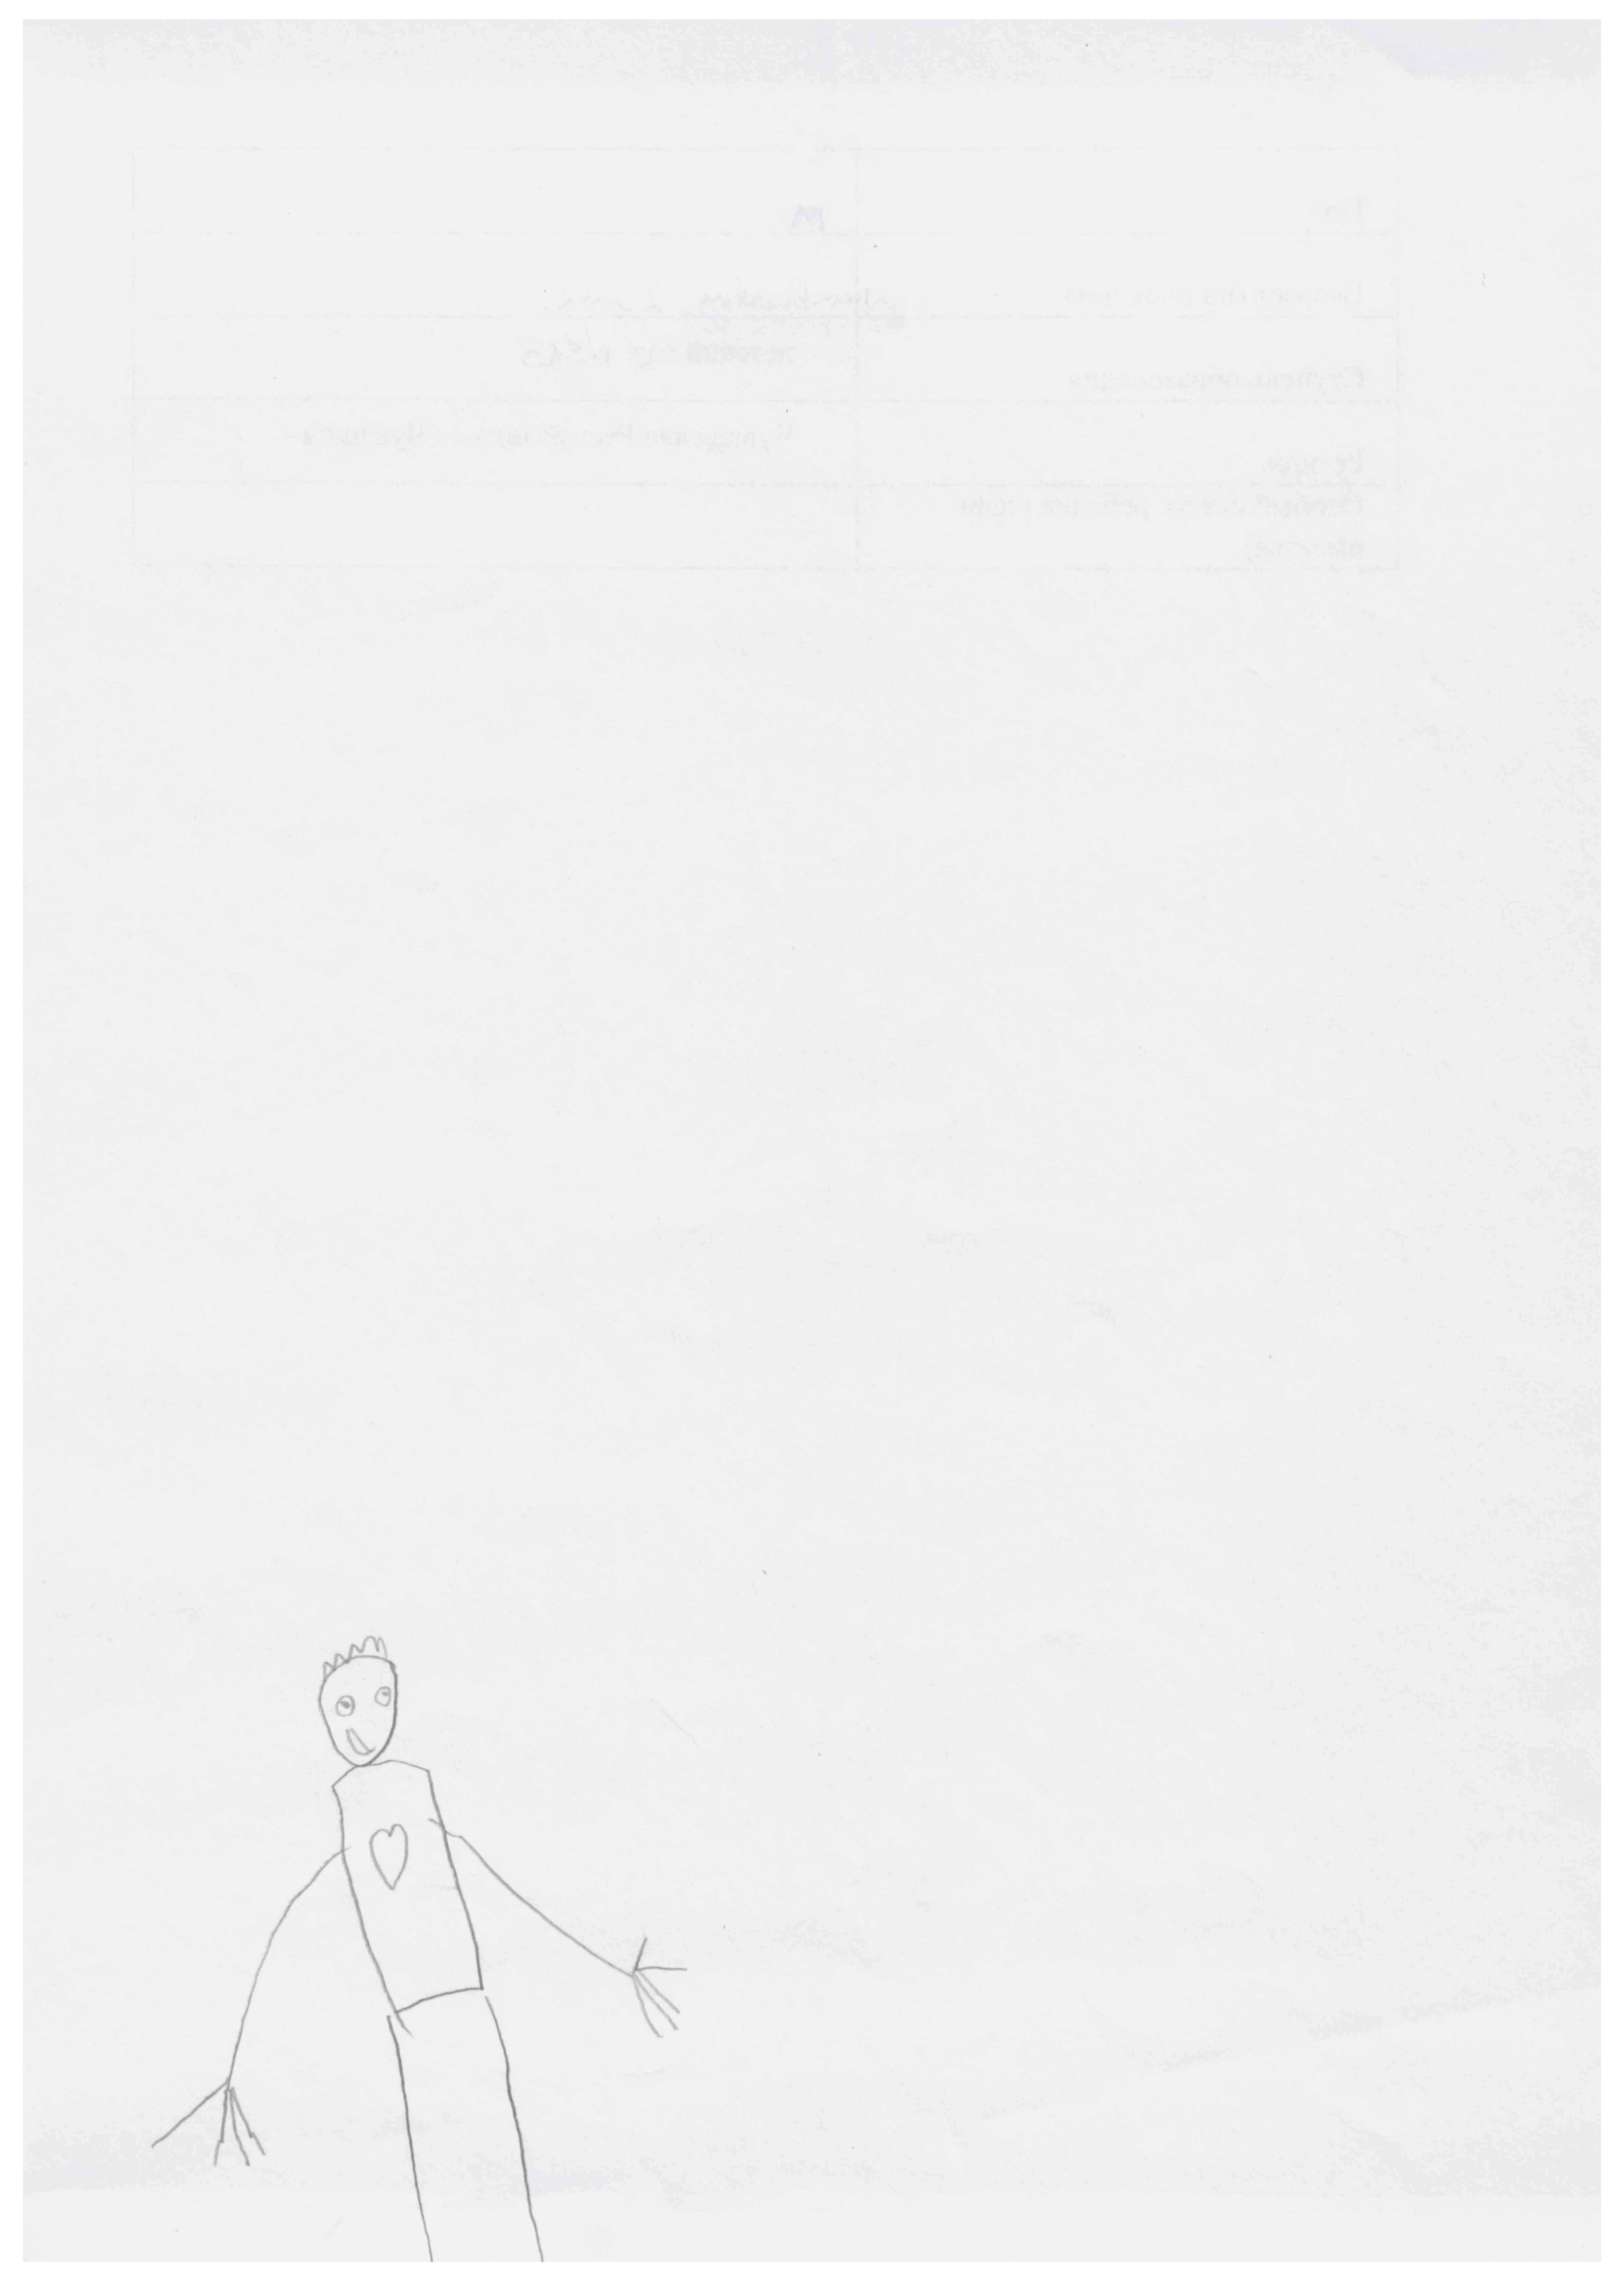

In [9]:
from PIL import Image
from IPython.display import display

sample_idx = 14
sample = converted_dataset[sample_idx]
sample

image_ref = message_image_ref(sample)
print(f"Превью изображения из converted_dataset[{sample_idx}]: {image_ref}")
if image_ref:
    display(Image.open(image_ref))


## Загрузка модели Gemma4-Vision (Unsloth)


In [10]:
from unsloth import FastVisionModel

MODEL_NAME = "unsloth/gemma-4-E4B-it"
MAX_SEQ_LENGTH = 1536

model, processor = FastVisionModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
    trust_remote_code=True,
)

tokenizer = processor


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla V100-PCIE-32GB. Num GPUs = 1. Max memory: 31.733 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|████████████████████████████████████████████████████████████| 2130/2130 [00:04<00:00, 489.18it/s]


## LoRA (PEFT)


In [11]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


## Проверка генерации до обучения


In [12]:
FastVisionModel.for_inference(model)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {device}")

sample_idx = 14
sample = converted_dataset[sample_idx]
image_ref = message_image_ref(sample)
image = Image.open(image_ref)
print(f"Инференс по изображению из converted_dataset[{sample_idx}]: {image_ref}")

free_prompt = "Ты - профессиональный детский психолог. Объясни, что видишь на рисунке. Проведи подробный психологический анализ."
structured_prompt = instruction

from transformers import TextStreamer


def run_inference(prompt_text: str, max_new_tokens: int = 512):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt_text},
            ],
        }
    ]
    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to(device)

    text_streamer = TextStreamer(tokenizer, skip_prompt=True)
    with torch.inference_mode():
        _ = model.generate(
            **inputs,
            streamer=text_streamer,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            temperature=0.2,
            top_p=0.9,
            top_k=64,
        )


print("\n=== Инференс до обучения: свободный анализ ===")
run_inference(free_prompt, max_new_tokens=512)

print("\n=== Инференс до обучения: структурированный вывод ===")
run_inference(structured_prompt, max_new_tokens=512)

FastVisionModel.for_training(model)


Устройство: cuda
Инференс по изображению из converted_dataset[14]: /storage/dremov/diploma/datasets/train_vlm_300/ЧУВ5лмдс_39.png

=== Инференс до обучения: свободный анализ ===
Как профессиональный детский психолог, я готов провести анализ представленного рисунка.

**Важное замечание:** Поскольку вы предоставили мне только очень маленький фрагмент документа, содержащий этот рисунок, мой анализ будет основан исключительно на том, что видно в нижней части изображения. Я буду интерпретировать этот рисунок как самостоятельный образец, который ребенок мог нарисовать.

---

## 🎨 Психологический анализ рисунка

### 1. Описание рисунка (Что я вижу)

На рисунке изображена **очень простая, схематичная фигура человека**.

*   **Фигура:** Это "человечек" (фигурка-палочка), выполненный минималистично.
*   **Голова:** Круглая, с нарисованными глазами и, возможно, улыбкой (хотя детализация минимальна).
*   **Тело:** Прямоугольное или вертикальное.
*   **Деталь:** В центре груди (на теле) нарисовано 

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma4ForConditionalGeneration(
      (model): Gemma4Model(
        (language_model): Gemma4TextModel(
          (embed_tokens): Gemma4TextScaledWordEmbedding(262144, 2560, padding_idx=0)
          (layers): ModuleList(
            (0): Gemma4TextDecoderLayer(
              (self_attn): Gemma4TextAttention(
                (q_norm): Gemma4RMSNorm()
                (k_norm): Gemma4RMSNorm()
                (v_norm): Gemma4RMSNorm()
                (k_proj): lora.Linear4bit(
                  (base_layer): Linear4bit(in_features=2560, out_features=512, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2560, out_features=16, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=16, ou

## Обучение (SFTTrainer)


In [13]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

OUTPUT_DIR = BASE_PATH / "outputs"
LOG_DIR = OUTPUT_DIR / "logs" / "tb"
LOG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FastVisionModel.for_training(model)

split = converted_dataset.train_test_split(test_size=0.1, seed=3407, shuffle=True)
train_dataset = split["train"]
eval_dataset = split["test"]

sft_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    logging_dir=str(LOG_DIR),
    report_to="tensorboard",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    warmup_ratio=0.03,
    num_train_epochs=1,
    learning_rate=3e-4,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=20,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    seed=3407,
    max_grad_norm=1.0,
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    remove_unused_columns=False,
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
    max_length=MAX_SEQ_LENGTH,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    args=sft_args,
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Unsloth: Model does not have a default image size - using 512


In [ ]:
trainer_stats = trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
20,8.402917,0.920612
40,0.354586,0.864864
60,0.008467,0.875285
80,0.004709,0.861465


Unsloth: Not an error, but Gemma4ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


## Проверка генерации после обучения


In [ ]:
FastVisionModel.for_inference(model)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {device}")

sample_idx = 14
sample = converted_dataset[sample_idx]
image_ref = message_image_ref(sample)
image = Image.open(image_ref)
print(f"Инференс по изображению из converted_dataset[{sample_idx}]: {image_ref}")

free_prompt = "Ты - профессиональный детский психолог. Объясни, что видишь на рисунке. Проведи подробный психологический анализ."
structured_prompt = instruction

from transformers import TextStreamer


def run_inference(prompt_text: str, max_new_tokens: int = 1024):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt_text},
            ],
        }
    ]
    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to(device)

    text_streamer = TextStreamer(tokenizer, skip_prompt=True)
    with torch.inference_mode():
        _ = model.generate(
            **inputs,
            streamer=text_streamer,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            temperature=0.2,
            top_p=0.9,
            top_k=64,
        )


print("\n=== Инференс после обучения: свободный анализ ===")
run_inference(free_prompt, max_new_tokens=1024)

print("\n=== Инференс после обучения: структурированный вывод ===")
run_inference(structured_prompt, max_new_tokens=1024)


## Сохранение LoRA


In [ ]:
LORA_DIR = BASE_PATH / "gemma4_vlm_lora"
LORA_DIR.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(LORA_DIR))
tokenizer.save_pretrained(str(LORA_DIR))
